# Competitor defenses

PSBD is 1 of many detectors that sit in front of a deployed model and decide, 1 input at a time, whether the input carries a backdoor trigger. This repository ports 11 of them into `detectors/` so that all 13 defenses (the 11 plus PSBD-TM and PSBD-RD) are scored on the same models, the same images and the same thresholds. This notebook walks through every competitor: the idea in plain words, a figure of what it perturbs or reads, the source of its scoring function, the distribution of its scores on 2 real models and its AUROC per attack on the panel beside PSBD-TM and PSBD-RD. The per-detector pages under `docs/detectors/` hold the full record: the paper's equations with symbol tables, every deviation of the port and the generated tables per attack and poison rate.

The reader is assumed to know PyTorch and nothing about this repository or about backdoor detection. Every term is defined where it first appears.

**Map of the steps.**

1. The problem, the evaluation protocol and the panel of models.
2. Confidence, the null model every detector has to beat.
3. STRIP, entropy under superimposition.
4. SCALE-UP, label consistency under pixel amplification, in 2 variants.
5. IBD-PSC, retained confidence under LayerNorm amplification, in 2 variants.
6. TeCo, the spread of corruption breaking points.
7. CD-L, the size of the smallest input mask that keeps the logits.
8. Beatrix, Gram-matrix deviation from class bands.
9. TED, the nearest-neighbor rank trajectory over depth.
10. SentiNet, transplanting the salient region.
11. All 13 defenses side by side: accuracy, failures and cost.
12. Summary.

The notebook reads cached files only: `results/coverage/coverage.json`, every `results/<folder>/detectors/<name>_metrics.json` and `<name>_scores_*.pt`, every `results/<folder>/psbd_metrics.json` and 4 CIFAR-10 test images from `raw_data/` for the illustrations. It loads no trained model. Reading the records takes about a minute.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in the library resolves the
# same way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

In [2]:
import inspect
import logging
import statistics
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import detectors
from attacks import build_attack, default_config
from defenses.cache import read_split_manifest
from defenses.decision import pair_clean_to_backdoor
from detectors import beatrix, cd_l, confidence, ibd_psc, scale_up, sentinet, strip, teco, ted
from evaluation.loaders import load_test_base
from scripts.detector_doc_results import collect_readings, comparison_cells
from scripts.paper._common import BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED, attack_label, bootstrap_ci, dataset_label

import scripts.paper._style  # noqa: F401  the figure style every paper figure uses

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline

warnings.filterwarnings("ignore", category=UserWarning)
logging.getLogger("lightning.fabric.utilities.seed").setLevel(logging.WARNING)
torch.set_num_threads(8)
pd.set_option("display.max_colwidth", 80)

## Step 1. The problem, the protocol and the panel

**The problem.** A backdoor attack poisons a small share of a model's training set, the **poison rate**, so that the trained model behaves normally on ordinary images and sends any image carrying a secret pattern, the **trigger**, to a **target class** the attacker chose. The panel's attacks differ mostly in the trigger: BadNets and TaCT stamp a small corner patch (TaCT's works only on images of 1 source class), Blend blends a fixed image over the whole input, BPP reduces the color depth, LF adds a smooth low-frequency pattern and WaNet warps the image slightly. SIG adds a sinusoidal signal to images already labeled as the target (a clean-label attack). An input-level detector sees 1 image at a time and must say whether it carries a trigger, knowing neither the trigger nor the target nor whether the model was attacked at all.

**PSBD and the 2 reference placements.** PSBD (Li et al., arXiv 2406.05826) perturbs the model $k$ times and flags an input whose confidence in its own prediction barely drops, because a trigger rides the most robust association the model learned. **PSBD-TM** perturbs by zeroing whole tokens at the input of every attention block, the placement this project recommends. **PSBD-RD** applies dropout to the residual stream after both residual adds of every block, this project's adaptation of the PSBD paper's ResNet placement. `notebooks/placements-and-operators.ipynb` explains both.

**The splits.** `data.splits.build_psbd_loaders_from_checkpoint` shuffles each dataset's clean test set once with seed 0. The first 2000 images are the **validation split**, the only clean data any detector may fit on or read a threshold from. The rest is the analysis pool: the **clean split** is those images as they are and the **backdoor split** is every image the attack may act on with the trigger applied. `defenses.decision.pair_clean_to_backdoor` restricts the clean side to the same photographs, so every comparison is between the same images with and without the trigger.

**The numbers.** Every detector returns 1 score per image with **low meaning poisoned**. `defenses.decision.detection_report` computes

$$
\tau_q = \operatorname{quantile}_q\{ s(x) : x \in V \}, \qquad \mathrm{TPR}_q = \Pr_{x \in B}\big[ s(x) < \tau_q \big], \qquad \mathrm{AUROC} = \Pr\big[ s(x_b) < s(x_c) \big] + \tfrac{1}{2}\Pr\big[ s(x_b) = s(x_c) \big]
$$

| symbol | meaning |
|---|---|
| $s(x)$ | the detector's score of image $x$ |
| $V$, $B$, $C$ | the validation, backdoor and paired clean splits |
| $q$ | the false-positive budget, 0.10 or 0.20 in the tables below |
| $\tau_q$ | the threshold, the $q$ quantile of the clean validation scores |
| $\mathrm{TPR}_q$ | the share of triggered images flagged at that threshold |
| $x_b$, $x_c$ | a random triggered image and a random clean image |
| $\mathrm{AUROC}$ | the probability a triggered image scores lower than a clean one, ties counted as half |

AUROC is **one-sided**: it is computed on the scores as the detector returns them and never flipped, so a value under 0.5 means the detector ordered the 2 populations the wrong way round. PSBD-TM and PSBD-RD are read at the **adaptive rule**, the smallest perturbation rate whose clean validation images change their prediction in 80% of perturbed passes, which a defender can apply without any triggered data.

**The panel.** `scripts.detector_doc_results.comparison_cells` returns the models of the paper's detector comparison: the ViT-B/16 models in `results/coverage/coverage.json` that are successful backdoors (attack success at the bar and clean accuracy within the headline bar of the benign model, the ledger's `successful_2pt`), on CIFAR-10, CIFAR-100, GTSRB and Tiny ImageNet, excluding models that diverged in training or whose TaCT poisoning mapped the whole source class to the target, and keeping only those every 1 of the 13 defenses has scored. `collect_readings` then reads every record. The table shows how many panel models each attack and poison rate contributes, and every per-attack figure below carries those counts.

In [3]:
cells = comparison_cells("results")
readings = collect_readings("results", cells)
print(f"{len(cells)} models, {len(readings)} defenses: {', '.join(readings)}")

per_model = pd.DataFrame(
    [
        {"defense": defense, "folder": row["folder"], "attack": attack_label(row["attack"]), "rate": row["poison_rate"], "dataset": dataset_label(row["dataset"]), "AUROC": row["AUROC"], "TPR10": row["TPR at 10% FPR"], "TPR20": row["TPR at 20% FPR"]}
        for defense, rows in readings.items()
        for row in rows
    ]
)
composition = per_model[per_model["defense"] == "PSBD-TM"].pivot_table(index="attack", columns="rate", values="folder", aggfunc="count", fill_value=0)
composition.columns = [f"{rate:.0%}" for rate in composition.columns]
composition

56 models, 13 defenses: PSBD-TM, PSBD-RD, confidence, strip, scale_up, scale_up_data_limited, ibd_psc, ibd_psc_calibrated, teco, cd_l, beatrix, ted, sentinet


,1%,5%,10%
attack,,,
BPP,4,4,4
BadNets,4,4,4
Blend,4,4,4
LF,4,4,4
Label-Consistent,0,1,0
TaCT,2,2,0
WaNet,0,1,2


In [4]:
ATTACK_ORDER = sorted(per_model["attack"].unique())
MODELS_PER_ATTACK = per_model[per_model["defense"] == "PSBD-TM"]["attack"].value_counts()
REFERENCE_STYLES = {"PSBD-TM": dict(color="#009E73", hatch=""), "PSBD-RD": dict(color="#D55E00", hatch="..")}
DETECTOR_STYLES = [dict(color="#0072B2", hatch="//"), dict(color="#56B4E9", hatch="xx")]
EXAMPLE_MODELS = ("vit_cifar100_badnet_a2o_0_01", "vit_cifar10_wanet_0_1")


def show_source(function):
    print(inspect.getsource(function))


def per_attack_figure(names, title):
    # Mean AUROC per attack for the named detectors and both PSBD placements, with
    # the number of models behind each attack in the tick labels.
    columns = list(names) + ["PSBD-TM", "PSBD-RD"]
    means = per_model[per_model["defense"].isin(columns)].pivot_table(index="attack", columns="defense", values="AUROC", aggfunc="mean").reindex(index=ATTACK_ORDER, columns=columns)
    figure, axis = plt.subplots(figsize=(6.9, 2.8))
    width = 0.8 / len(columns)
    for index, column in enumerate(columns):
        style = REFERENCE_STYLES.get(column) or DETECTOR_STYLES[index % len(DETECTOR_STYLES)]
        axis.bar(np.arange(len(ATTACK_ORDER)) + (index - len(columns) / 2 + 0.5) * width, means[column], width=width, label=column, edgecolor="black", linewidth=0.3, **style)
    axis.axhline(0.5, color="0.4", lw=0.8, ls=":")
    axis.set_xticks(range(len(ATTACK_ORDER)), labels=[f"{attack}\n(n={MODELS_PER_ATTACK[attack]})" for attack in ATTACK_ORDER], fontsize=6.5)
    axis.set_ylim(0, 1.02)
    axis.set_ylabel("mean one-sided AUROC")
    axis.set_title(title, fontsize=8, pad=18)
    axis.legend(loc="lower left", bbox_to_anchor=(0.0, 1.0), ncols=len(columns), fontsize=6.5)
    plt.show()
    summary = per_model[per_model["defense"].isin(columns)].groupby("defense")[["AUROC", "TPR10", "TPR20"]].mean().reindex(columns).round(3)
    summary["models below chance"] = per_model[per_model["defense"].isin(columns)].groupby("defense")["AUROC"].apply(lambda values: int((values < 0.5).sum())).reindex(columns)
    return summary


def score_figure(name):
    # The score distributions of 1 detector on the 2 example models, triggered
    # images against their clean twins, with the threshold at a 10% budget.
    figure, axes = plt.subplots(1, 2, figsize=(6.9, 2.3))
    for axis, folder in zip(axes, EXAMPLE_MODELS):
        directory = f"results/{folder}/detectors"
        clean = torch.load(f"{directory}/{name}_scores_clean.pt")
        backdoor = torch.load(f"{directory}/{name}_scores_backdoor.pt")
        paired_clean = pair_clean_to_backdoor(clean, read_split_manifest(f"results/{folder}/psbd"))
        record = next(row for row in readings[name] if row["folder"] == folder)["record"]
        threshold = record["detection"]["q0.10"]["threshold"]
        edges = np.histogram_bin_edges(np.concatenate([paired_clean.numpy(), backdoor.numpy()]), bins=40)
        axis.hist(paired_clean.numpy(), bins=edges, alpha=0.55, color="#0072B2", label="clean")
        axis.hist(backdoor.numpy(), bins=edges, alpha=0.55, color="#D55E00", hatch="//", label="triggered")
        axis.axvline(threshold, color="black", lw=0.9, ls="--", label="threshold, 10% budget")
        axis.set_title(f"{folder}, AUROC {record['detection']['q0.25']['auroc']:.3f}", fontsize=7)
        axis.set_xlabel(f"{name} score, low means poisoned")
        axis.set_yscale("log")
    axes[0].set_ylabel("images, log scale")
    axes[0].legend(fontsize=6)
    plt.show()


test_images, _ = load_test_base("cifar10", "raw_data")
clean_image = test_images[7][0]  # (3, 32, 32) in [0, 1]
overlay_images = torch.stack([test_images[index][0] for index in (11, 23, 42)])  # (3, 3, 32, 32)
badnet = build_attack("badnet_a2o", default_config("badnet_a2o"), 32, 0)
triggered_image = badnet.apply_trigger(clean_image, 7)  # (3, 32, 32)
print("example image", tuple(clean_image.shape), "trigger changes", int((triggered_image != clean_image).any(dim=0).sum()), "pixels")


def show_images(rows, row_labels, column_labels, title):
    figure, axes = plt.subplots(len(rows), len(rows[0]), figsize=(1.05 * len(rows[0]) + 0.8, 1.15 * len(rows) + 0.4), squeeze=False)
    for axis_row, images, label in zip(axes, rows, row_labels):
        for axis, image, column in zip(axis_row, images, column_labels):
            axis.imshow(image.permute(1, 2, 0).clamp(0, 1).numpy(), interpolation="nearest")
            axis.set_xticks([])
            axis.set_yticks([])
            axis.grid(False)
            axis.set_title(column, fontsize=6)
        axis_row[0].set_ylabel(label, fontsize=7)
    figure.suptitle(title, fontsize=8)
    plt.show()

example image (3, 32, 32) trigger changes 9 pixels


**How to read the figures of each step.** The score figure draws the detector's scores on 2 real panel models, BadNets at 1% on CIFAR-100 (a patch trigger at the lowest poison rate) and WaNet at 10% on CIFAR-10 (a whole-image warp): blue is the clean images, orange hatched the same images triggered, the dashed line the threshold at a 10% false-positive budget and the y axis is logarithmic so thin tails stay visible. A detector separates when the orange mass sits left of the blue mass. The per-attack figure draws the mean AUROC over the panel models of each attack for the detector (blue hatched) beside PSBD-TM (green) and PSBD-RD (orange dotted), with n under each attack and chance as the dotted line. Attacks with 1 or 3 models (SIG, TaCT) say little on their own. The table under it gives the panel means of AUROC and TPR at 10% and 20% budgets and how many models fell below chance. Neither figure shows the per-rate structure, which the detector's page in `docs/detectors/` tabulates.

## Step 2. Confidence, the null model

**Question.** How much of any detector's success could the model's own confidence explain?

**Idea.** A backdoor is trained to be unambiguous, so a triggered image usually gets a very confident prediction. The null model scores an image by its maximum softmax probability, negated so that low means poisoned, with 1 forward pass, no perturbation and no clean data. Any detector that does no better than this has not shown it measures anything specific to backdoors. **What it perturbs.** Nothing. **Port.** `detectors/confidence.py`, `confidence_scores`. **Page.** `docs/detectors/confidence.md`.

@torch.inference_mode()
def confidence_scores(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    use_bfloat16: bool = True,
) -> torch.Tensor:
    """Negated max softmax probability per sample, shape (N,), low meaning poisoned.

    Negated at the boundary so the shared convention holds. A backdoored model is
    usually more confident on a triggered input than on a clean one, so the raw
    statistic is high for poisoned, and returning it unnegated would read as a
    well-formed, exactly inverted result rather than as an error.
    """
    model.eval()

    batch_scores = []
    for images, _ in loader:
        probs = forward_probs(
            model, images, device, use_bfloat16
        )  # (batch, num_classes)
        batch_scores.append(-probs.max(dim=1).values.cpu())  # (batch,)

    if not batch_scores:
        return torch.empty(0)

    scores = torch.cat(batch_scores).float()  # (N,)
    return scores



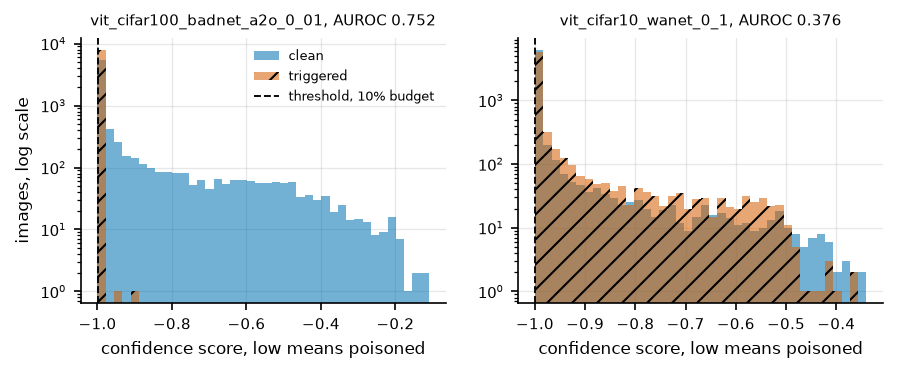

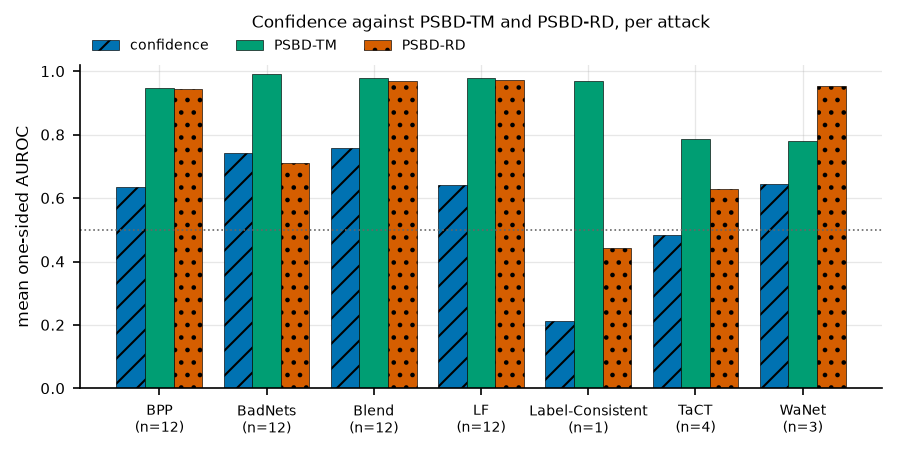

,AUROC,TPR10,TPR20,models below chance
defense,,,,
confidence,0.668,0.327,0.431,16
PSBD-TM,0.951,0.872,0.900,2
PSBD-RD,0.876,0.722,0.785,6


In [5]:
show_source(confidence.confidence_scores)
score_figure("confidence")
per_attack_figure(["confidence"], "Confidence against PSBD-TM and PSBD-RD, per attack")

**What it proves.** Confidence alone separates some attacks on some datasets and falls below chance on many models, most visibly where clean predictions are already near certain. PSBD-TM beats it on every attack of the panel. **What it does not.** It says nothing about attacks trained to keep the triggered prediction's confidence low, which are designed against exactly this signal. **Next question.** Does perturbing the input rather than just reading the output add information?

## Step 3. STRIP

**Question.** Does a trigger survive being blended with other images?

**Idea.** STRIP (Gao et al., ACSAC 2019) lays the input over $N$ clean images and measures the entropy of the prediction on each blend. A clean image's evidence is scrambled by the second image, so the predictions scatter and the entropy is high. A trigger survives the blend and keeps dragging the prediction to the target, so the entropy stays low. The score is the mean entropy, already low for poisoned. **What it perturbs.** The input pixels, by a saturating sum with a clean image. **Port.** `strip.strip_scores`, with $N = 8$ overlays taken from the first 8 validation images and the sum computed in pixel space and clipped to $[0, 1]$, as the reference's `cv2.addWeighted` does. **Page.** `docs/detectors/strip.md`. The figure blends a CIFAR-10 test image, clean and with the BadNets corner patch, with 3 other test images. The patch survives in every blend.

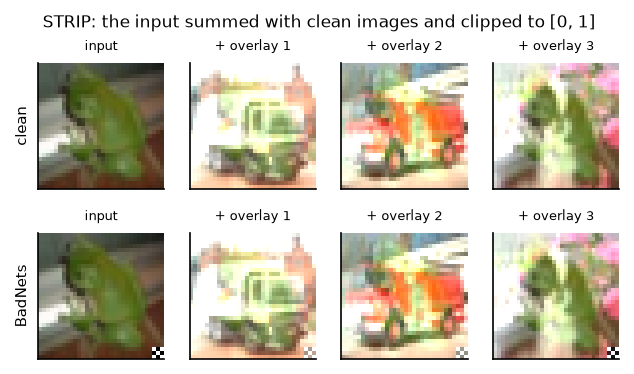

@torch.inference_mode()
def strip_scores(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    overlay_images: torch.Tensor,
    mean: tuple[float, ...],
    std: tuple[float, ...],
    use_bfloat16: bool = True,
    seed: int = 0,
    num_overlays: int = DEFAULT_NUM_OVERLAYS,
) -> torch.Tensor:
    """STRIP entropy per sample, shape (N,), low meaning poisoned.

    overlay_images is a (>=num_overlays, channels, height, width) batch of clean
    images, normally the output of collect_overlay_batch on the clean validation
    split.

    Returned as the raw entropy, not negated. STRIP's claim is that a triggered
    input has low entropy under superimposition, and low already means poisoned in
    the shared convention, so negating would invert the detector.
    """
    model.eval()
    seed_everything(seed)

    # overlays is (num_overlays, channels, height, width), normalized like images.
    overlays = overlay_images[:num_overlays].to(device)

    batch_scores 

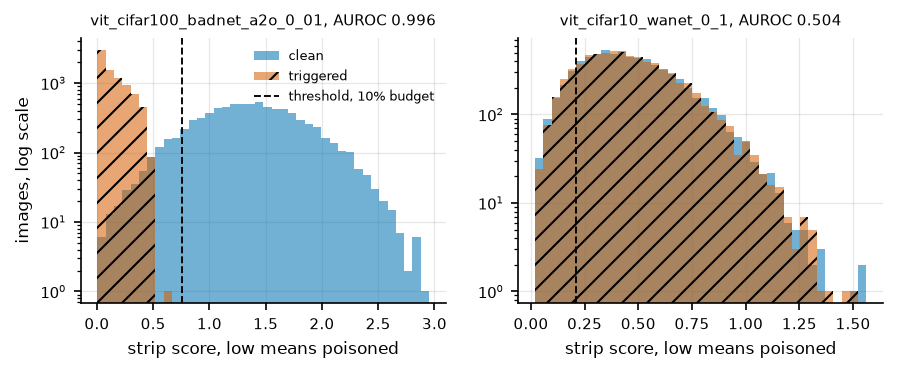

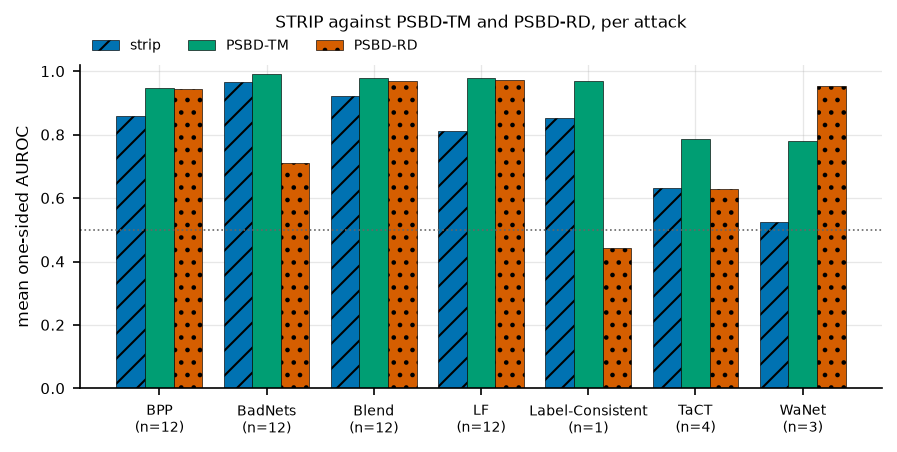

,AUROC,TPR10,TPR20,models below chance
defense,,,,
strip,0.852,0.696,0.773,1
PSBD-TM,0.951,0.872,0.900,2
PSBD-RD,0.876,0.722,0.785,6


In [6]:
blends_clean = [clean_image] + [(clean_image + overlay).clamp(0, 1) for overlay in overlay_images]
blends_triggered = [triggered_image] + [(triggered_image + overlay).clamp(0, 1) for overlay in overlay_images]
show_images([blends_clean, blends_triggered], ["clean", "BadNets"], ["input", "+ overlay 1", "+ overlay 2", "+ overlay 3"], "STRIP: the input summed with clean images and clipped to [0, 1]")
show_source(strip.strip_scores)
score_figure("strip")
per_attack_figure(["strip"], "STRIP against PSBD-TM and PSBD-RD, per attack")

**What it proves.** STRIP is the strongest black-box competitor on the panel and almost never inverts. It is strongest on BadNets and weakest on WaNet (near chance) and on TaCT, whose trigger needs its source class's content, which a blend with another image removes. **What it does not.** STRIP is known to be evaded by attacks that keep the triggered prediction's margin thin (Section VI-F of its paper). **Next question.** Is there a cheaper input perturbation that needs only labels?

## Step 4. SCALE-UP, data-free and data-limited

**Question.** Does a trigger survive amplification of every pixel?

**Idea.** SCALE-UP (Guo et al., ICLR 2023) multiplies every pixel by $n \in \{3, 5, 7, 9, 11\}$, clips to $[0, 1]$ and counts the share of amplified copies whose label equals the unamplified label, the scaled prediction consistency $SPC(x)$. Amplification washes an ordinary image out and changes its label, while a high-contrast trigger survives. `scale_up` is that statistic, negated. `scale_up_data_limited` standardizes it by the mean and standard deviation of clean $SPC$ within the predicted class as fitted on the validation split. It scores the validation split itself out of fit with 2 folds. **What it perturbs.** The input pixels, by multiplication and clipping. **Port.** `scale_up.spc_scores`, `amplify_pixels`, `fit_class_spc_statistics` and `standardize_spc`. **Page.** `docs/detectors/scale_up.md`. The figure amplifies the clean and triggered example image at every factor.

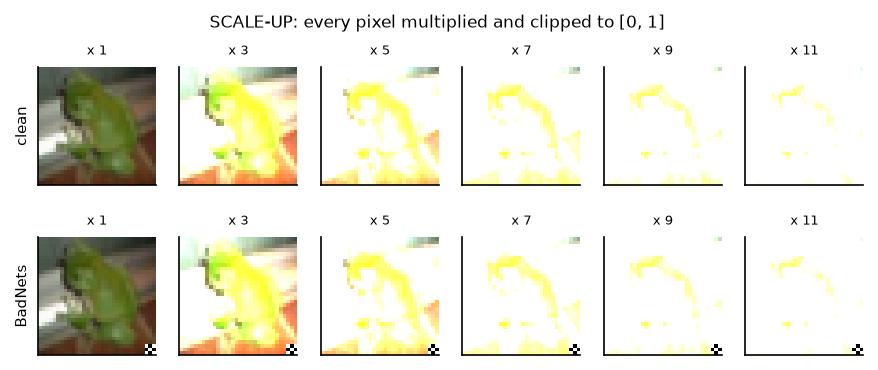

@torch.inference_mode()
def spc_scores(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    mean: tuple[float, ...],
    std: tuple[float, ...],
    scales: tuple[int, ...] = PAPER_SCALES,
    use_bfloat16: bool = True,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Raw SPC per sample plus the 2 things the data-limited variant needs.

    Returns (spc, predicted_labels, true_labels), each (N,). spc is Eq. (2) in
    [0, 1], high for poisoned. predicted_labels is C(x) and true_labels is
    whatever the loader served, which the caller needs to group Eq. (3) by class.

    Not negated. Sign correction happens once, at the scoring boundary, so this
    stays the paper's statistic and can be compared to a published number directly.
    """
    model.eval()

    spc_batches = []
    predicted_batches = []
    label_batches = []
    for images, labels in loader:
        images = images.to(device)  # (batch, channels, height, width)
        mean_tensor, s

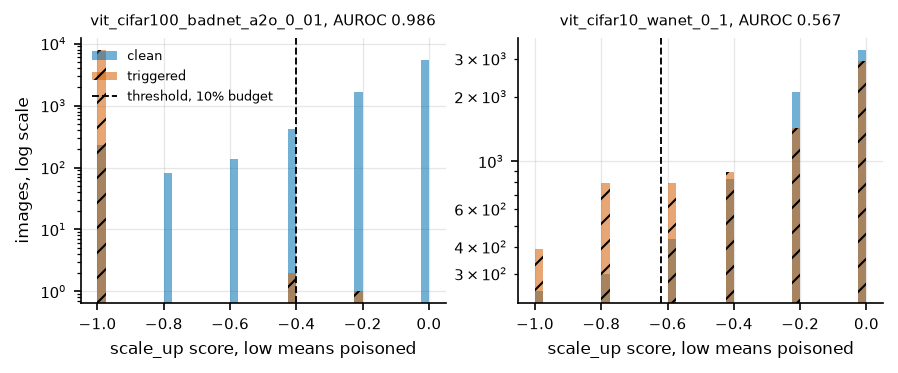

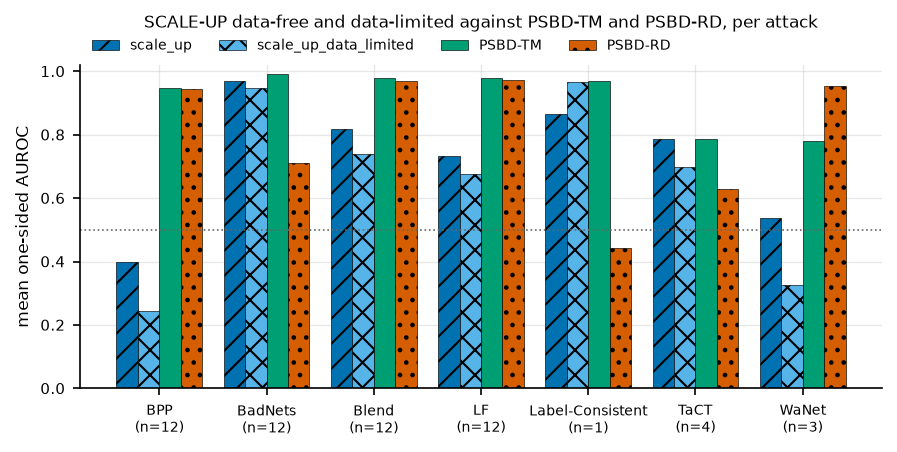

,AUROC,TPR10,TPR20,models below chance
defense,,,,
scale_up,0.726,0.328,0.499,9
scale_up_data_limited,0.644,0.365,0.519,17
PSBD-TM,0.951,0.872,0.900,2
PSBD-RD,0.876,0.722,0.785,6


In [7]:
zeros, ones = torch.zeros(1, 3, 1, 1), torch.ones(1, 3, 1, 1)
factors = (1, 3, 5, 7, 9, 11)
rows = [[scale_up.amplify_pixels(image[None], factor, zeros, ones)[0] for factor in factors] for image in (clean_image, triggered_image)]
show_images(rows, ["clean", "BadNets"], [f"x {factor}" for factor in factors], "SCALE-UP: every pixel multiplied and clipped to [0, 1]")
show_source(scale_up.spc_scores)
show_source(scale_up.standardize_spc)
score_figure("scale_up")
per_attack_figure(["scale_up", "scale_up_data_limited"], "SCALE-UP data-free and data-limited against PSBD-TM and PSBD-RD, per attack")

**What it proves.** Both variants work on BadNets, whose patch survives amplification exactly as the paper's mechanism says, and fall below chance on BPP and, for the data-limited variant, on WaNet: a low-amplitude trigger is destroyed by amplification along with the image. The data-limited variant is worse than the data-free one here, because with about 20 validation images per class on CIFAR-100 and 10 on Tiny ImageNet the per-class standard deviation of a 6-valued statistic is too noisy to divide by. **What it does not.** The paper's own evaluation used ResNets at 100 clean images per class, which this panel does not reproduce. **Next question.** What if the model's parameters, rather than the input, are amplified?

## Step 5. IBD-PSC, faithful and calibrated

**Question.** Does a triggered prediction survive amplification of the normalization layers nearest the head?

**Idea.** IBD-PSC (Hou et al., ICML 2024) multiplies the scale and shift of the last $k$ normalization layers by $\omega$, which inflates the features they pass on. Clean predictions resting on a comparison between similar logits flip, while a triggered prediction resting on a large margin keeps its label. The score is the mean probability 5 amplified models (depths $k$ to $k + 4$) give the unamplified prediction, negated. The paper's Algorithm 1 chooses $k$ as the first depth where the clean error exceeds 60%. The paper amplifies BatchNorm, which a ViT does not have, so the port amplifies the 25 affine LayerNorms of ViT-B/16, which is exact per layer since scaling $\gamma$ and $\beta$ together scales the output. At the paper's $\omega = 1.5$ the clean error never reaches 60% on most ViT models, so `ibd_psc_calibrated` searches $\omega$ over 1.5, 2, 3, 5 and 8 and stops at the first that lets Algorithm 1 work. **What it perturbs.** Model parameters. **Port.** `ibd_psc.amplifiable_norm_layers`, `select_start_layer_count`, `calibrate_scaling_factor` and `psc_scores`. **Page.** `docs/detectors/ibd_psc.md`. The figure shows which of the 25 LayerNorms each ensemble member amplifies, at the median start depth $k$ each variant fitted on the panel, read from the records' provenance.

calibrated omega chosen, models per value: {1.5: 6, 2.0: 38, 3.0: 12}


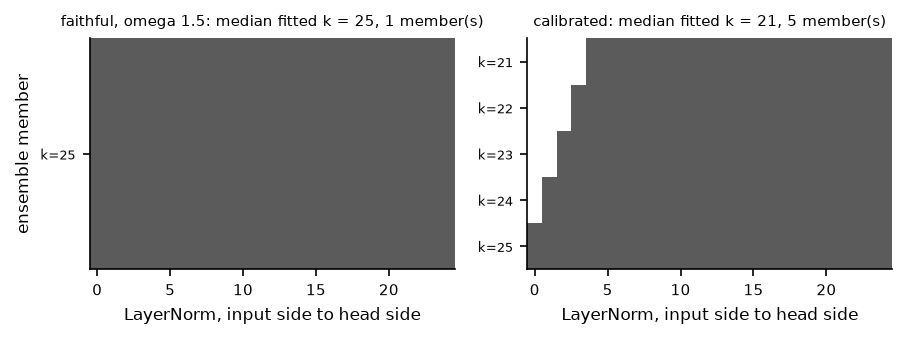

@torch.inference_mode()
def psc_scores(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    ordered_layers: list[nn.LayerNorm],
    start_layer_count: int,
    scaling_factor: float = DEFAULT_SCALING_FACTOR,
    ensemble_size: int = DEFAULT_ENSEMBLE_SIZE,
    use_bfloat16: bool = True,
) -> torch.Tensor:
    """Eq. (4): raw PSC per sample, shape (N,), high for poisoned.

    y' is taken from the unamplified model once per batch and never recomputed per
    ensemble member, which is what makes this a measure of retained agreement with
    the deployed model rather than of internal ensemble agreement.

    Not negated. Sign correction happens once, in ibd_psc_scores, so this stays
    the paper's statistic and can be compared to a published number directly.
    """
    model.eval()
    total_layers = len(ordered_layers)
    member_counts = [
        count
        for count in range(start_layer_count, start_layer_count + ensemble_size)
        if count <= total_lay

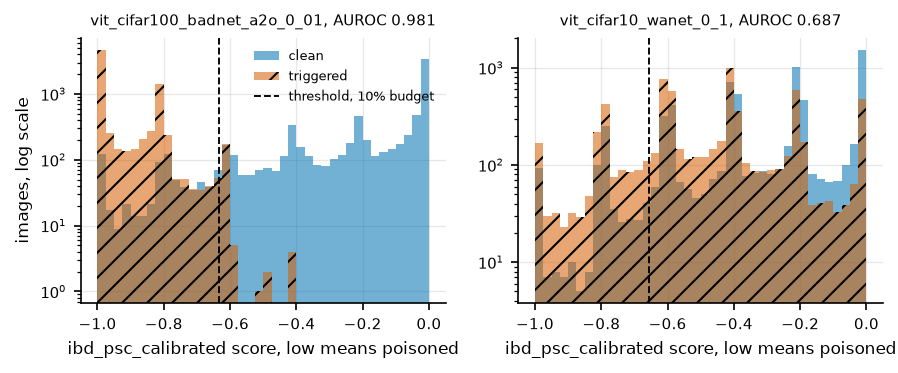

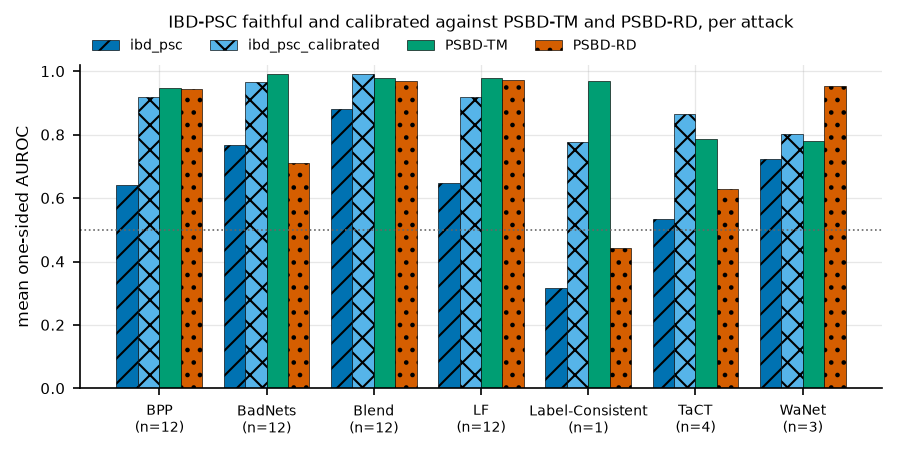

,AUROC,TPR10,TPR20,models below chance
defense,,,,
ibd_psc,0.713,0.386,0.500,14
ibd_psc_calibrated,0.933,0.808,0.892,0
PSBD-TM,0.951,0.872,0.900,2
PSBD-RD,0.876,0.722,0.785,6


In [8]:
def fitted_values(name, key):
    return pd.Series([row["record"]["provenance"]["hyperparameters"][key] for row in readings[name]])


faithful_k = int(fitted_values("ibd_psc", "start_layer_count").median())
calibrated_k = int(fitted_values("ibd_psc_calibrated", "start_layer_count").median())
calibrated_omega = fitted_values("ibd_psc_calibrated", "scaling_factor").value_counts().sort_index()
print("calibrated omega chosen, models per value:", calibrated_omega.to_dict())

LAYERS = 25  # 2 LayerNorms per block over 12 blocks plus the final LayerNorm
figure, axes = plt.subplots(1, 2, figsize=(6.9, 2.0))
for axis, (label, start) in zip(axes, [("faithful, omega 1.5", faithful_k), ("calibrated", calibrated_k)]):
    members = [count for count in range(start, start + ibd_psc.DEFAULT_ENSEMBLE_SIZE) if count <= LAYERS]
    grid = np.zeros((len(members), LAYERS))
    for row, count in enumerate(members):
        grid[row, LAYERS - count:] = 1  # the last count layers, counted from the head
    axis.imshow(grid, cmap="Greys", aspect="auto", vmin=0, vmax=1.4)
    axis.set_title(f"{label}: median fitted k = {start}, {len(members)} member(s)", fontsize=7)
    axis.set_xlabel("LayerNorm, input side to head side")
    axis.set_yticks(range(len(members)), labels=[f"k={count}" for count in members], fontsize=6)
    axis.grid(False)
axes[0].set_ylabel("ensemble member")
plt.show()
show_source(ibd_psc.psc_scores)
score_figure("ibd_psc_calibrated")
per_attack_figure(["ibd_psc", "ibd_psc_calibrated"], "IBD-PSC faithful and calibrated against PSBD-TM and PSBD-RD, per attack")

**Reading the figure.** Each row is 1 ensemble member and gray cells are its amplified layers. At the paper's factor the median start depth is the last possible 1, so the ensemble collapses to a single model with every LayerNorm amplified, which on most models still leaves predictions intact. After calibration the median start depth moves inward and the full ensemble of 5 is used, although on models whose fitted depth lies within 4 layers of the head the ensemble is still clamped to fewer members. **What it proves.** The calibrated variant is the strongest competitor on the panel and never falls below chance, and it beats PSBD-TM on Blend. The faithful variant at the paper's factor is near the bottom, a failure of scale on this architecture rather than of the idea. **What it does not.** The calibration ladder is this project's choice, not the paper's, so the calibrated numbers are the method adapted, not the method as published. **Next question.** Can a detector with no clean data at all do as well by corrupting the input?

## Step 6. TeCo

**Question.** Does a triggered image break at more scattered corruption severities than a clean one?

**Idea.** TeCo (Liu et al., CVPR 2023) applies common image corruptions at severities 1 to 5 and records, per corruption, the lowest severity at which the prediction changes. A clean image's evidence erodes at similar rates under every corruption, so its breaking points cluster. A trigger survives some corruptions and not others, so its breaking points scatter. The score is the standard deviation of the breaking points, negated. **What it perturbs.** The input, with 14 of the 15 corruptions of Hendrycks and Dietterich's benchmark (`frost` needs bundled photographs and is dropped). **Port.** `teco.hardness_thresholds` and `teco.deviation`, each corruption reimplemented in torch in `detectors/teco.py`. **Page.** `docs/detectors/teco.md`. The figure applies every corruption at severities 1, 3 and 5 to the triggered example image.

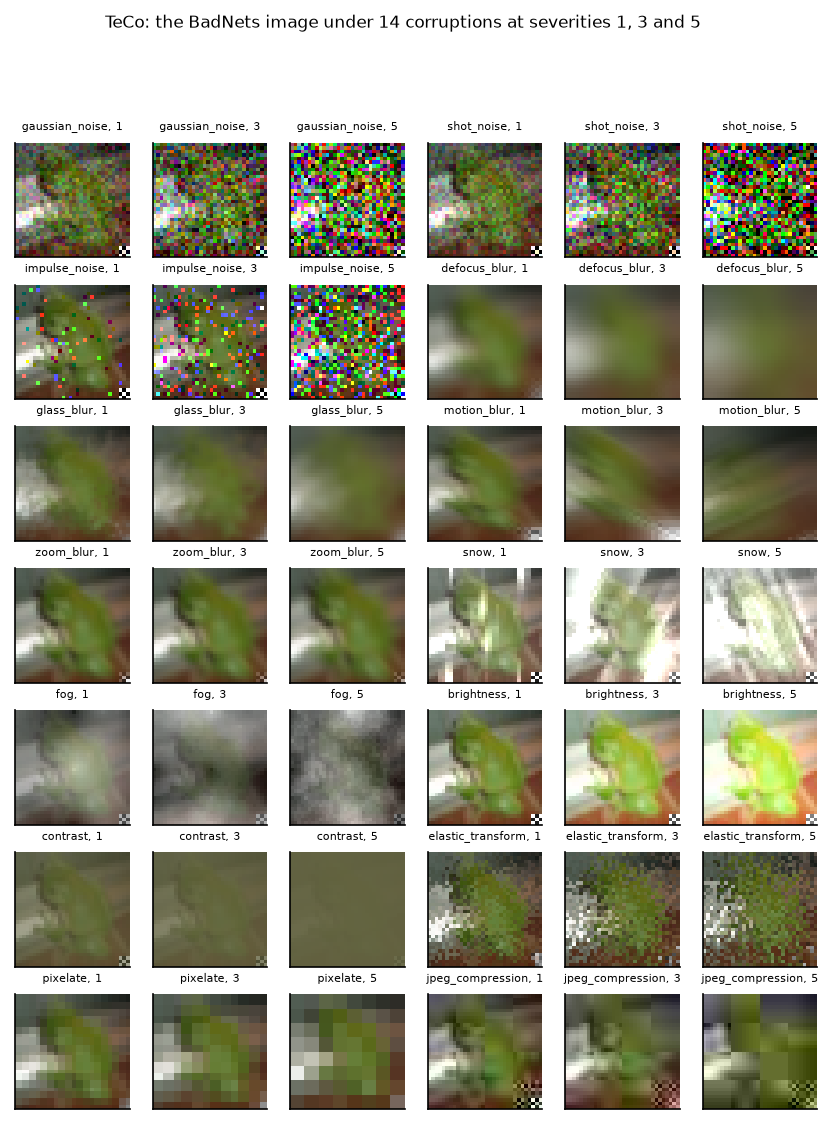

@torch.inference_mode()
def hardness_thresholds(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    mean: tuple[float, ...],
    std: tuple[float, ...],
    corruptions: tuple[str, ...] = DEFAULT_CORRUPTIONS,
    max_severity: int = MAX_SEVERITY,
    use_bfloat16: bool = True,
    seed: int = 0,
) -> torch.Tensor:
    """The set L of Algorithm 1 for every sample, shape (N, len(corruptions)).

    Entry (i, k) is the lowest severity at which corruption k moved sample i's
    prediction away from P_org, or max_severity + 1 when it never did.

    The ascending severity scan with the still-at-sentinel guard is exactly
    Algorithm 1's break: once a sample has recorded a threshold for a corruption,
    a later severity cannot overwrite it. Every severity is still evaluated, which
    is what the released code does and what makes the pass batchable.
    """
    model.eval()
    seed_everything(seed)

    unknown = [name for name in corruptions if name not in CORRUP

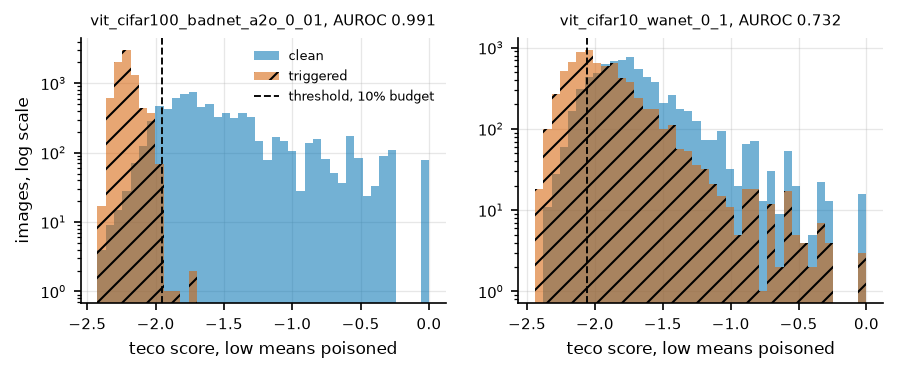

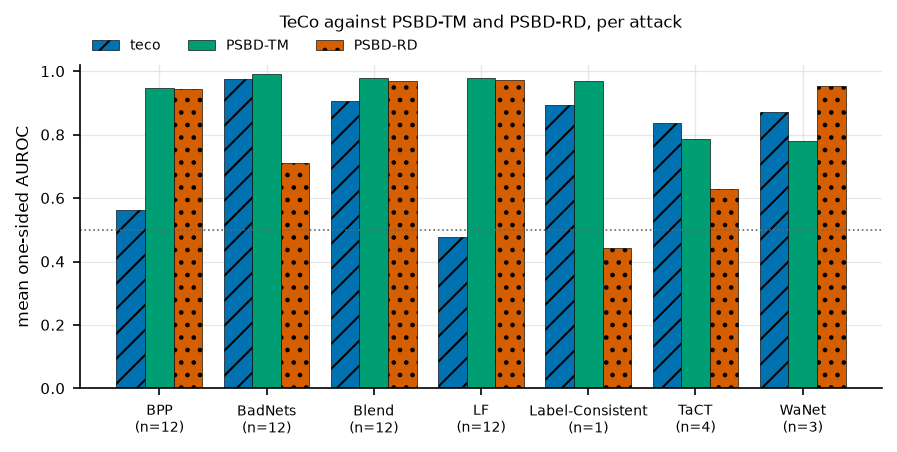

,AUROC,TPR10,TPR20,models below chance
defense,,,,
teco,0.748,0.497,0.596,12
PSBD-TM,0.951,0.872,0.900,2
PSBD-RD,0.876,0.722,0.785,6


In [9]:
torch.manual_seed(0)
severities = (1, 3, 5)
names = list(teco.DEFAULT_CORRUPTIONS)
rows = [[teco.CORRUPTIONS[name](triggered_image[None], severity)[0] for severity in severities] for name in names]
figure, axes = plt.subplots(len(names) // 2, 6, figsize=(6.9, 8.4))
for index, (name, images) in enumerate(zip(names, rows)):
    for offset, (image, severity) in enumerate(zip(images, severities)):
        axis = axes[index // 2, (index % 2) * 3 + offset]
        axis.imshow(image.permute(1, 2, 0).clamp(0, 1).numpy(), interpolation="nearest")
        axis.set_xticks([])
        axis.set_yticks([])
        axis.grid(False)
        axis.set_title(f"{name}, {severity}", fontsize=5.5)
figure.suptitle("TeCo: the BadNets image under 14 corruptions at severities 1, 3 and 5", fontsize=8)
plt.show()
show_source(teco.hardness_thresholds)
score_figure("teco")
per_attack_figure(["teco"], "TeCo against PSBD-TM and PSBD-RD, per attack")

**What it proves.** TeCo separates BadNets well, Blend reasonably and WaNet better than PSBD-TM does, likely because a warp survives the photometric corruptions and breaks under the geometric ones, which this repository has not measured. It fails on BPP and LF, falling below chance on LF at higher rates: a color-depth or low-frequency trigger is destroyed by every corruption at about the rate the image content is, so its breaking points cluster like a clean image's. It costs 71 forward passes per input. **What it does not.** The port's corruptions are torch reimplementations whose agreement with the original package is not covered by a committed test (`docs/detectors/README.md`). **Next question.** Instead of corrupting the input blindly, can a detector search for the part of the input the model relies on?

## Step 7. CD-L

**Question.** How small a region of the input does the model need to reproduce its logits?

**Idea.** Cognitive Distillation (Huang et al., ICLR 2023) learns, for each input, a mask $m$ over its pixels by 100 Adam steps on $\lVert f(x) - f(x \odot m + (1 - m) \odot \delta) \rVert_1 + \alpha \lVert m \rVert_1 + \beta\, TV(m)$, where $\delta$ is a random color redrawn every step. The L1 term shrinks the mask and only pixels the logits depend on can hold it up. A clean image's logits rest on the whole object, so the mask stays large. A triggered image's logits rest on the trigger, so the mask collapses onto it. The score is the mask's L1 norm, already low for poisoned. **What it perturbs.** The input, through an optimized mask. **Port.** `cd_l.distill_masks` and `cd_l.mask_norms`, with the mask at the image's native 32 or 64 pixels and gradients to the mask only. **Page.** `docs/detectors/cd_l.md`. The figure shows Eq. (2) of the paper, $x \odot m + (1 - m) \odot \delta$, with 2 hand-drawn masks, 1 over the trigger corner and 1 over the whole image, on the triggered example. It illustrates what the optimization compares and is not an optimized mask, which needs the trained model.

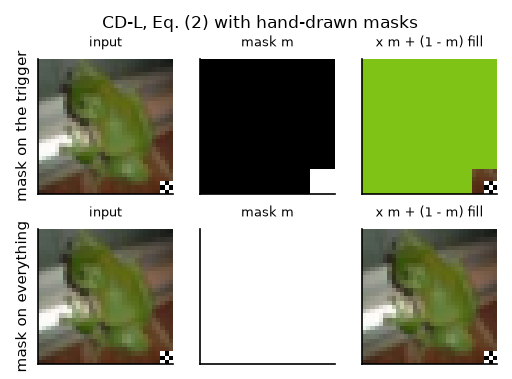

def distill_masks(
    model: nn.Module,
    images: torch.Tensor,
    mean: tuple[float, ...],
    std: tuple[float, ...],
    device: torch.device,
    use_bfloat16: bool,
    learning_rate: float = DEFAULT_LEARNING_RATE,
    l1_weight: float = DEFAULT_L1_WEIGHT,
    tv_weight: float = DEFAULT_TV_WEIGHT,
    num_steps: int = DEFAULT_NUM_STEPS,
) -> torch.Tensor:
    """Eq. (1) solved for 1 batch, the final effective masks, (batch, 1, height, width).

    images is the batch exactly as the loader serves it, normalized and at the
    dataset's native resolution. The reference logits come from that tensor. The
    mask is optimized in [0, 1] pixel space at the same resolution, the Eq. (2)
    blend is renormalized with the same statistics, and the model's own Resize
    takes the distilled input up to 224.

    The model is frozen for the whole loop and the gradient is taken against the
    mask parameter alone, so no model parameter ever receives a .grad. Nothing
    here runs under in

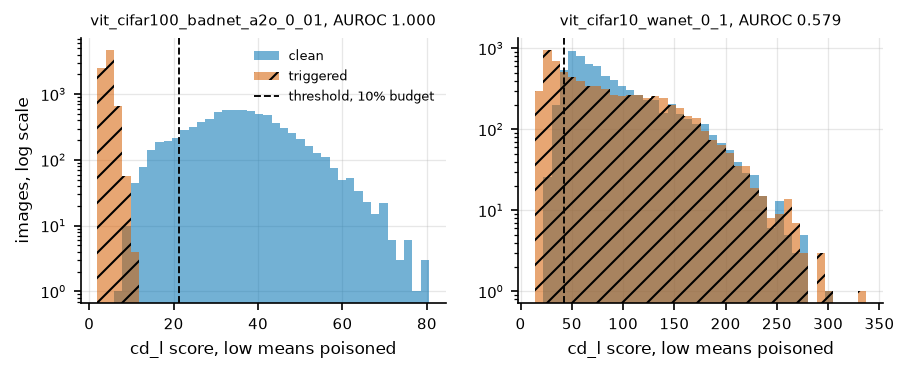

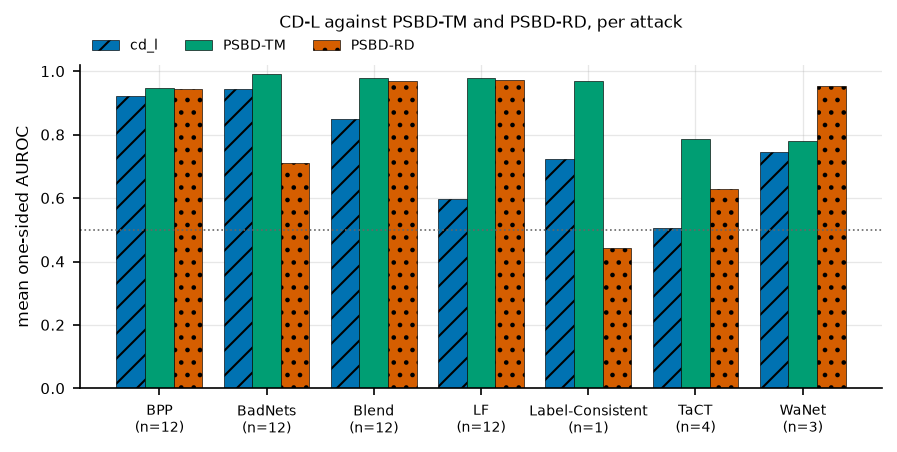

,AUROC,TPR10,TPR20,models below chance
defense,,,,
cd_l,0.799,0.520,0.667,8
PSBD-TM,0.951,0.872,0.900,2
PSBD-RD,0.876,0.722,0.785,6


In [10]:
torch.manual_seed(0)
corner_mask = torch.zeros(1, 32, 32)
corner_mask[:, -6:, -6:] = 1.0
full_mask = torch.ones(1, 32, 32)
fill = torch.rand(3, 1, 1)
rows = [[triggered_image, mask.expand(3, -1, -1), triggered_image * mask + (1 - mask) * fill] for mask in (corner_mask, full_mask)]
show_images(rows, ["mask on the trigger", "mask on everything"], ["input", "mask m", "x m + (1 - m) fill"], "CD-L, Eq. (2) with hand-drawn masks")
show_source(cd_l.distill_masks)
score_figure("cd_l")
per_attack_figure(["cd_l"], "CD-L against PSBD-TM and PSBD-RD, per attack")

**What it proves.** CD-L is strong on BadNets and BPP and weak on LF, WaNet and TaCT: a whole-image trigger gives the mask no small region to collapse onto, and TaCT's trigger needs its source object in the mask too. It costs 251 forward-equivalents per input, the most of any defense. BPP is also a whole-image trigger, and CD-L's success on it is not explained here. **What it does not.** The port runs its 100 steps in bfloat16, validated against float32 on 1 model only. **Next question.** Instead of the input, can a detector read the model's internal features directly?

## Step 8. Beatrix

**Question.** Does a triggered image produce feature correlations its predicted class never shows?

**Idea.** Beatrix (Ma et al., NDSS 2023) reads 1 intermediate layer, forms the Gram matrix of its features (every feature dimension multiplied with every other, summed over positions) at orders $p = 1$ to 4, and compares each entry with a band, the median plus or minus 10 median absolute deviations over clean images the model assigns to the same class. The score is the mean relative excess outside the band, negated. **What it reads.** The residual stream at the output of block 9 of 12, 197 tokens by 768 dims, with the Gram contracted over tokens so it is 768 by 768. **Port.** `beatrix.gram_features`, `fit_class_bands`, `gram_deviation` and the 5-fold `jackknife_deviations` that scores the validation split out of fit. **Page.** `docs/detectors/beatrix.md`. The figure computes the order-1 to order-4 Gram matrices with the port's own `gram_features` on a small random token matrix (16 tokens by 8 dims), to show the object, not a measurement.

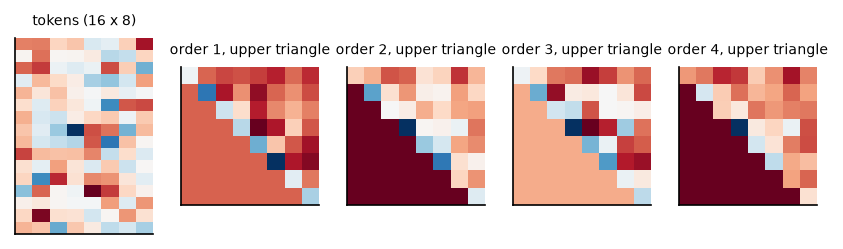

def gram_deviation(
    features: torch.Tensor,
    lower: torch.Tensor,
    upper: torch.Tensor,
    gram_entries: int,
    num_powers: int,
) -> torch.Tensor:
    """Eq. (12) to (14), the deviation of each row of features, (batch,), high for poisoned.

    lower and upper are (features,) for a shared band or (batch, features) for a
    band gathered per row, and the feature count must equal gram_entries *
    num_powers, the n(n + 1) P / 2 of Eq. (14) the sum is divided by. The
    denominators follow the released code, |min + 1e-6| rather than |min|.
    """
    num_features = gram_entries * num_powers
    widths = (features.shape[-1], lower.shape[-1], upper.shape[-1])
    if any(width != num_features for width in widths):
        raise ValueError(
            f"features, lower and upper have widths {widths}, expected "
            f"{gram_entries} Gram entries times {num_powers} orders = {num_features}"
        )

    below = (
        F.relu(lower - features) / (lower + RELATIVE_E

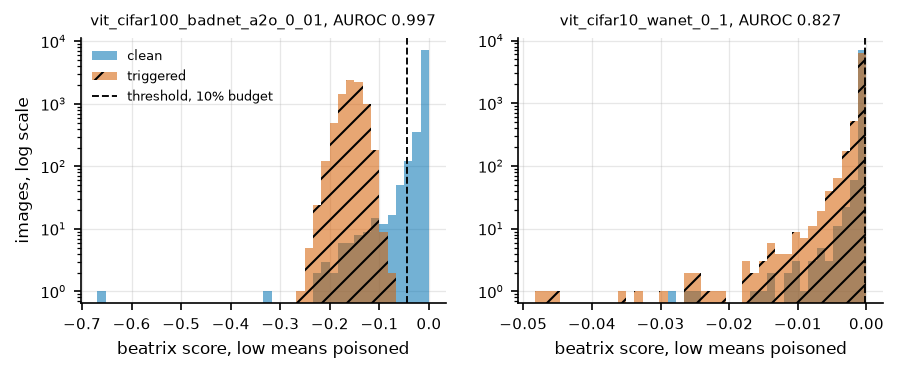

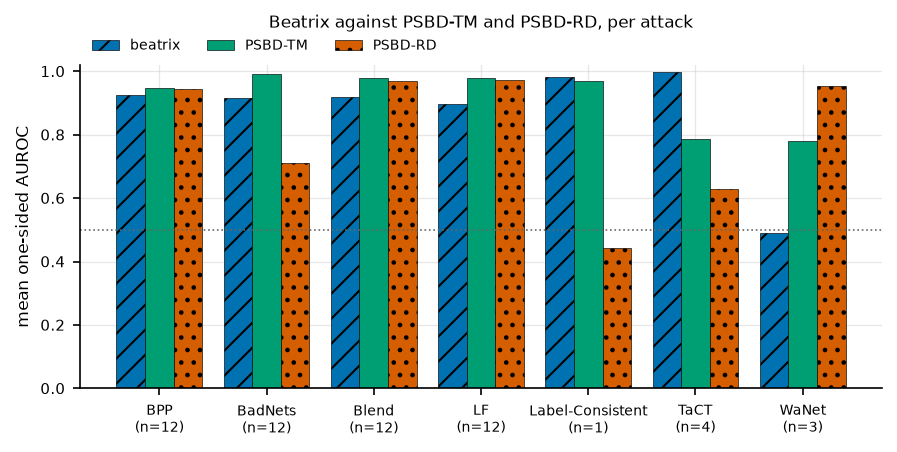

,AUROC,TPR10,TPR20,models below chance
defense,,,,
beatrix,0.899,0.678,0.733,2
PSBD-TM,0.951,0.872,0.900,2
PSBD-RD,0.876,0.722,0.785,6


In [11]:
torch.manual_seed(0)
toy_tokens = torch.randn(1, 16, 8)  # (batch, tokens, dim)
features = beatrix.gram_features(toy_tokens, beatrix.PAPER_POWERS)  # (1, 4 * 36)
rows, columns = torch.triu_indices(8, 8)
figure, axes = plt.subplots(1, 5, figsize=(6.9, 1.7))
axes[0].imshow(toy_tokens[0].numpy(), cmap="RdBu", aspect="auto")
axes[0].set_title("tokens (16 x 8)", fontsize=6.5)
entries = rows.numel()
for axis, power in zip(axes[1:], beatrix.PAPER_POWERS):
    gram = torch.zeros(8, 8)
    gram[rows, columns] = features[0, (power - 1) * entries : power * entries]
    axis.imshow(gram.numpy(), cmap="RdBu")
    axis.set_title(f"order {power}, upper triangle", fontsize=6.5)
for axis in axes:
    axis.set_xticks([])
    axis.set_yticks([])
    axis.grid(False)
plt.show()
show_source(beatrix.gram_deviation)
score_figure("beatrix")
per_attack_figure(["beatrix"], "Beatrix against PSBD-TM and PSBD-RD, per attack")

**What it proves.** Beatrix is third of the 13 defenses on the panel and the best of all on CIFAR-10, and it separates TaCT almost perfectly. It fails on WaNet, whose warp moves every token a little. Its weakness is the class budget: on Tiny ImageNet the shared split leaves about 10 references per class, so the bands are read off very few images (`docs/detectors/beatrix.md` gives the per-dataset means). **What it does not.** The feature layer is fixed at block 9 by analogy with the paper's ResNet hook, and no other layer was swept. **Next question.** Can the depth at which a triggered image's features change class be used directly?

## Step 9. TED

**Question.** Does a triggered image's neighborhood change class later in the network than a clean image's?

**Idea.** TED (Mo et al., IEEE S&P 2024) stores the clean validation images the model classifies correctly with their activations at every block boundary. For an input, at each layer it sorts the stored images by distance and records the position of the first 1 with the input's predicted class. A clean image is among its class at every depth, so its ranks stay small. A triggered image looks like its source class until the backdoor takes over late, so its early ranks are large. An outlier model fitted on the stored images' own trajectories scores the input, negated. **What it reads.** The residual stream at all 13 block boundaries of ViT-B/16, flattened. **Port.** `ted.collect_reference_bank`, `first_same_class_rank`, `fit_trajectory_model` and `outlier_scores`, with the pyod PCA detector of the reference notebook replaced by a squared Mahalanobis distance. **Page.** `docs/detectors/ted.md`. The figure runs the port's own `first_same_class_rank` on toy 2-dimensional features at 5 layers: a bank of 2 classes whose clusters stay put, a clean query of class 1 that sits in cluster 1 throughout, and a triggered query predicted as class 1 that sits in cluster 0 until layer 4. The data are synthetic, chosen to show the mechanism.

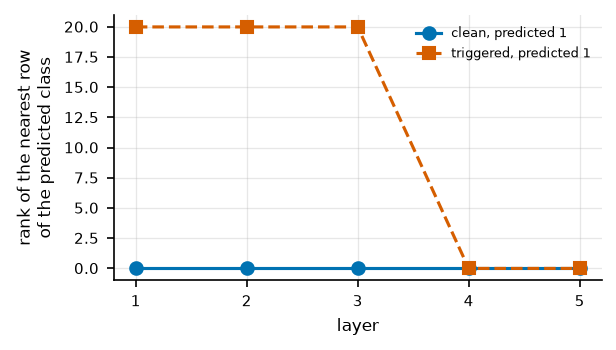

def first_same_class_rank(
    queries: torch.Tensor,
    query_labels: torch.Tensor,
    bank: torch.Tensor,
    bank_labels: torch.Tensor,
    exclude_self: torch.Tensor | None = None,
    chunk_size: int = DISTANCE_CHUNK,
) -> torch.Tensor:
    """Algorithm 2 lines 11 to 13 at 1 layer for a batch of queries, (batch,) long.

    queries is (batch, features) and bank (bank_size, features) in any float
    dtype, query_labels (batch,) and bank_labels (bank_size,) long. exclude_self
    is None or (batch,) long naming the bank row each query is a copy of, with -1
    for a query that is no bank row. The named row is masked to an infinite
    distance, which is what the notebook's ranking_array[1:] does for a bank row
    ranked against its own bank.

    The rank is the 0-based position of the first bank row carrying the query's
    label in the bank sorted by euclidean distance to the query, so a rank of 0
    means the nearest row already has that label. A query whose label appears
  

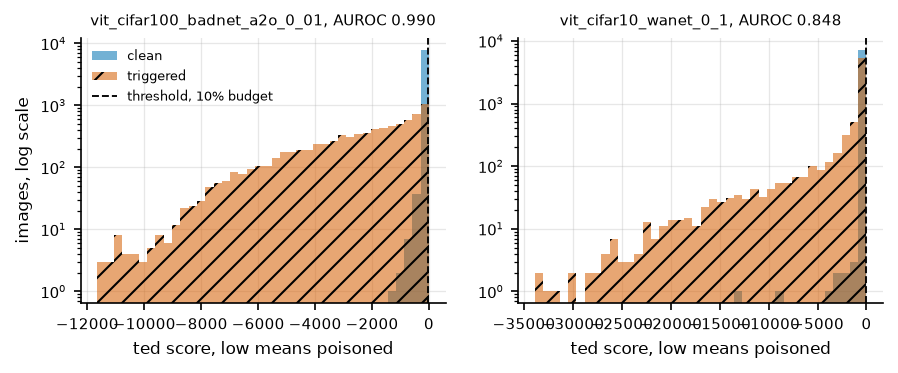

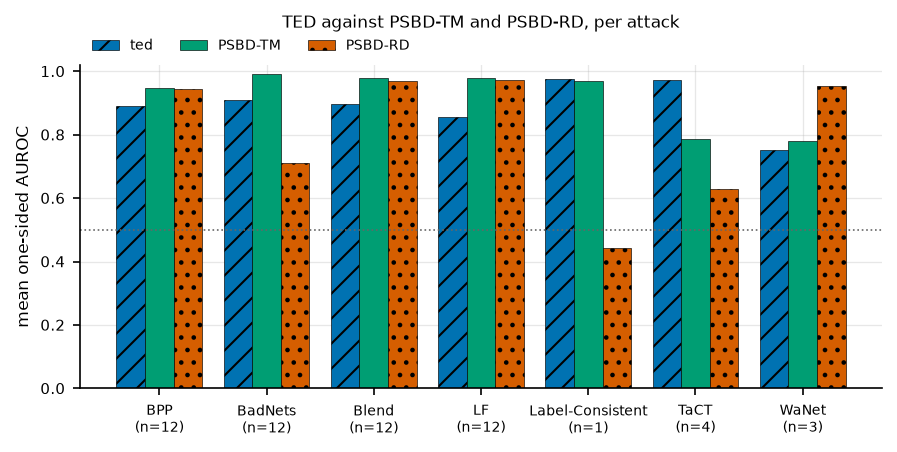

,AUROC,TPR10,TPR20,models below chance
defense,,,,
ted,0.889,0.712,0.790,0
PSBD-TM,0.951,0.872,0.900,2
PSBD-RD,0.876,0.722,0.785,6


In [12]:
torch.manual_seed(0)
layers = 5
bank_labels = torch.tensor([0] * 20 + [1] * 20)
bank = torch.cat([torch.randn(20, 2) + torch.tensor([-3.0, 0.0]), torch.randn(20, 2) + torch.tensor([3.0, 0.0])])  # (40, 2)
clean_query = torch.tensor([[3.0, 0.5]])  # sits in cluster 1 at every layer
trajectories = {"clean, predicted 1": [], "triggered, predicted 1": []}
for layer in range(layers):
    triggered_query = torch.tensor([[-3.0 + 6.0 * max(0, layer - 2) / 2, 0.3]])  # leaves cluster 0 only from layer 3 on
    for label, query in (("clean, predicted 1", clean_query), ("triggered, predicted 1", triggered_query)):
        rank = ted.first_same_class_rank(query, torch.tensor([1]), bank, bank_labels)
        trajectories[label].append(int(rank))
figure, axis = plt.subplots(figsize=(4.2, 2.3))
for (label, ranks), style in zip(trajectories.items(), (dict(color="#0072B2", marker="o", ls="-"), dict(color="#D55E00", marker="s", ls="--"))):
    axis.plot(range(1, layers + 1), ranks, label=label, **style)
axis.set_xlabel("layer")
axis.set_ylabel("rank of the nearest row\nof the predicted class")
axis.set_xticks(range(1, layers + 1))
axis.legend(fontsize=6)
plt.show()
show_source(ted.first_same_class_rank)
score_figure("ted")
per_attack_figure(["ted"], "TED against PSBD-TM and PSBD-RD, per attack")

**What it proves.** TED is fourth of 13, just above PSBD-RD, never falls below chance and is near perfect on TaCT, whose early-layer features stay with the source class. Like Beatrix it is weakest on Tiny ImageNet, where the shared split leaves few stored images per class. **What it does not.** The outlier model differs from the reference's, so its numbers are not the paper's. **Next question.** Can the region that drives the prediction be located and tested directly?

## Step 10. SentiNet

**Question.** Does the region that drives the prediction hijack other images when transplanted?

**Idea.** SentiNet (Chou et al., IEEE S&P Workshops 2020) finds the salient region with Grad-CAM, pastes it onto 100 clean images and counts how many take the input's label (`fooled`), then pastes noise into the same spot and records the mean confidence (`avg_conf`). A small trigger fools nearly every image and hides little of it, so it sits high in both. A curve fitted over clean images bounds the benign region of the plane of `avg_conf` against `fooled`. The score is the negated height above that curve. **What it perturbs.** Clean images, by transplanting a region of the input or noise into them. **Port.** `sentinet.grad_cam`, `saliency_mask`, `overlay_statistics`, `fit_decision_boundary` and `boundary_residual`. On ViT, Grad-CAM reads the input of the last block, since the head reads only the class token and the last block's patch outputs carry no gradient. **Page.** `docs/detectors/sentinet.md`. The figure builds both composites with a hand-drawn mask around the trigger corner, the region an ideal Grad-CAM map would find. On the real models the map misses the trigger, which is the point of the results below.

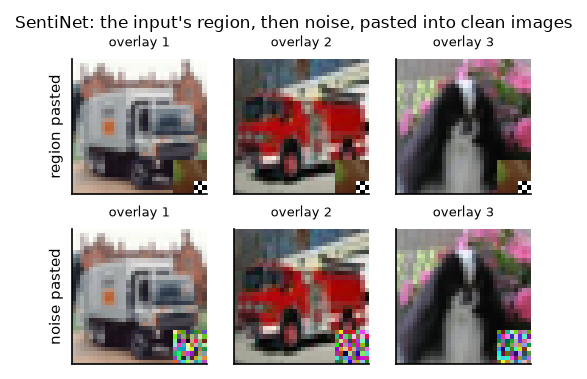

@torch.inference_mode()
def overlay_statistics(
    model: nn.Module,
    pixels: torch.Tensor,
    masks: torch.Tensor,
    predicted: torch.Tensor,
    overlay_pixels: torch.Tensor,
    inert_pixels: torch.Tensor,
    mean: tuple[float, ...],
    std: tuple[float, ...],
    device: torch.device,
    use_bfloat16: bool,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Algorithm 3's 2 statistics for a batch, (fooled, avg_conf), each (batch,) float32.

    original form
        X_R    = Overlay(X, x * mask),   X_IP = Overlay(X, IP)
        fooled = | { x_R in X_R : f(x_R) = y } |
        avgconf_IP = (1 / |X|) * sum conf_IP
    descriptive form
        adversarial = overlay outside the mask, the input inside it
        inert       = overlay outside the mask, uniform noise inside it
        fooled      = fraction of adversarial copies predicted as the input's label
        avg_conf    = mean max softmax over the inert copies

    pixels is (batch, channels, height, width) in [0, 1], masks


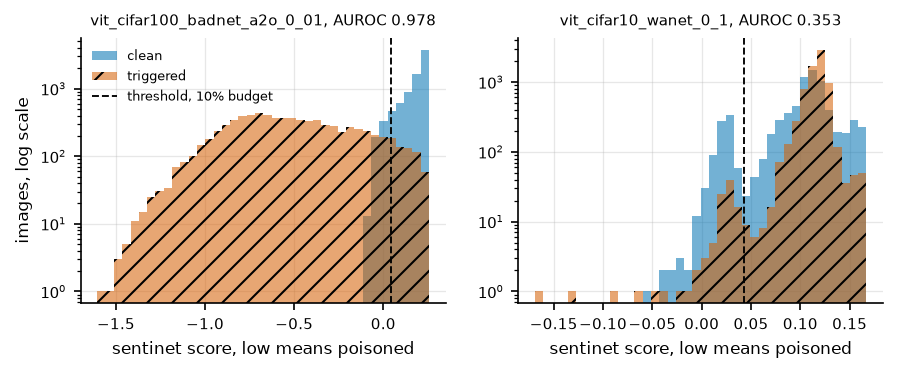

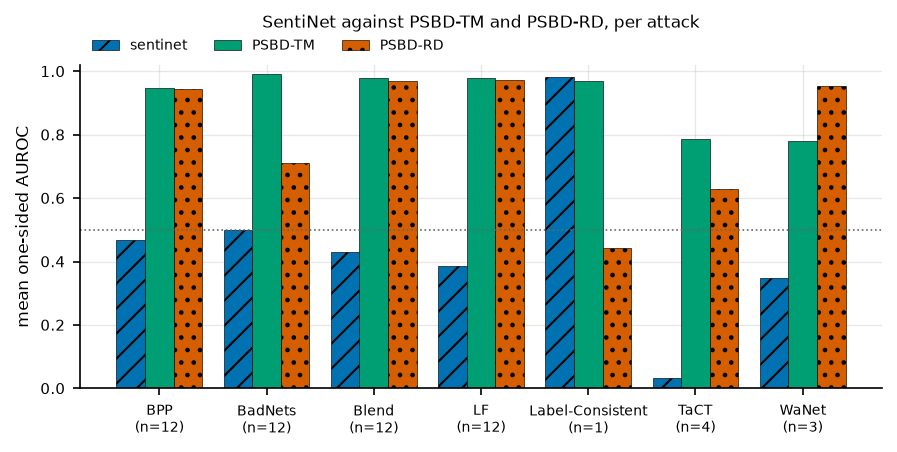

,AUROC,TPR10,TPR20,models below chance
defense,,,,
sentinet,0.421,0.116,0.185,39
PSBD-TM,0.951,0.872,0.900,2
PSBD-RD,0.876,0.722,0.785,6


In [13]:
torch.manual_seed(0)
region = torch.zeros(1, 32, 32)
region[:, -8:, -8:] = 1.0
noise = torch.rand(3, 3, 32, 32)
adversarial = [overlay * (1 - region) + triggered_image * region for overlay in overlay_images]
inert = [overlay * (1 - region) + patch * region for overlay, patch in zip(overlay_images, noise)]
show_images([adversarial, inert], ["region pasted", "noise pasted"], ["overlay 1", "overlay 2", "overlay 3"], "SentiNet: the input's region, then noise, pasted into clean images")
show_source(sentinet.overlay_statistics)
score_figure("sentinet")
per_attack_figure(["sentinet"], "SentiNet against PSBD-TM and PSBD-RD, per attack")

**What it proves.** SentiNet is last and below chance on most panel models, lowest on TaCT. The established part of the explanation is that Grad-CAM on these ViTs does not point at the trigger (`docs/runs/2026-09-10-detector-smoke.md`), so the transplanted region carries part of the object, not the trigger. That explains a reading near chance, not below it (Q23 of `docs/open-questions.md`). A candidate explanation for the sign, not yet measured, is that `fooled` counts against the input's predicted label: a triggered input is predicted as the target while its transplanted region shows the source object, so it fools fewer clean images than a clean input's region does. **What it does not.** It does not test an attention-based mask, the natural ViT variant, which was never built. **Next question.** How do all 13 defenses compare once each has been seen?

## Step 11. All 13 defenses side by side

**Question.** Which defense separates best on the panel? How often does each invert, and what does each cost?

**Measured.** The left figure ranks every defense by its mean AUROC over the panel with a 95% bootstrap interval of the mean over models (5000 resamples, seed 0, `scripts.paper._common.bootstrap_ci`). The right figure plots the same mean against the forward passes each defense spends per scored input, from `detectors.FORWARD_PASSES_PER_INPUT`, with PSBD counted as 4 (1 unperturbed pass and $k = 3$ perturbed passes) on a logarithmic axis. The table adds the paired gap of PSBD-TM over each defense, the mean over models of PSBD-TM's AUROC minus the defense's AUROC on the same model, with its interval.

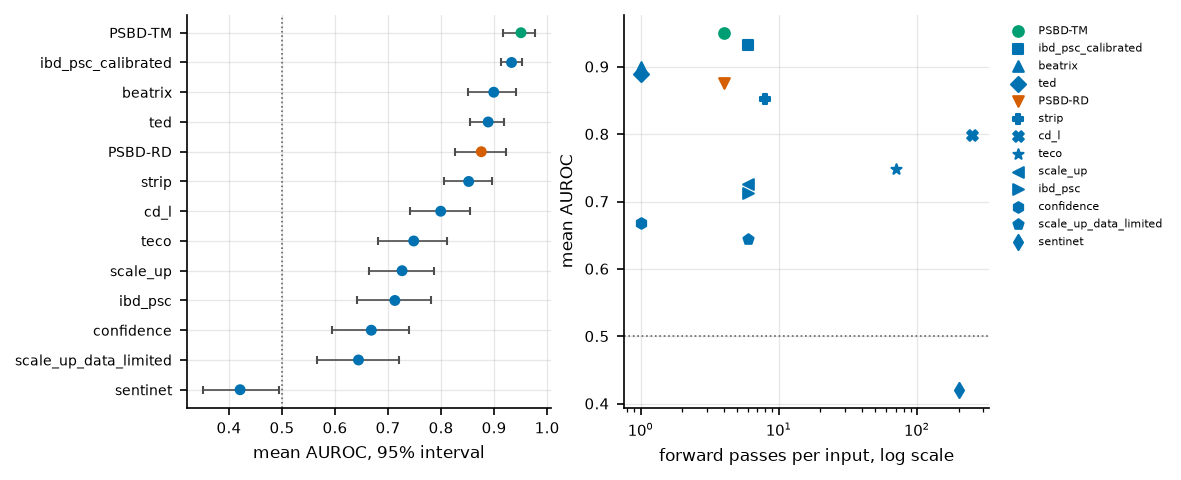

,mean AUROC,low,high,below chance,forward passes,PSBD-TM minus defense
defense,,,,,,
PSBD-TM,0.951,0.917,0.976,2,4,reference
ibd_psc_calibrated,0.933,0.912,0.952,0,6,"+0.018 [-0.017, +0.048]"
beatrix,0.899,0.851,0.941,2,1,"+0.051 [-0.002, +0.108]"
ted,0.889,0.855,0.919,0,1,"+0.062 [+0.017, +0.106]"
PSBD-RD,0.876,0.826,0.922,6,4,"+0.075 [+0.018, +0.134]"
strip,0.852,0.805,0.895,1,8,"+0.099 [+0.058, +0.143]"
cd_l,0.799,0.742,0.855,8,251,"+0.151 [+0.097, +0.210]"
teco,0.748,0.682,0.811,12,71,"+0.202 [+0.132, +0.276]"
scale_up,0.726,0.664,0.786,9,6,"+0.224 [+0.164, +0.287]"


In [14]:
names = list(readings)
order = sorted(names, key=lambda name: -per_model[per_model["defense"] == name]["AUROC"].mean())
rows = []
reference = per_model[per_model["defense"] == "PSBD-TM"].set_index("folder")["AUROC"]
for name in order:
    values = per_model[per_model["defense"] == name].set_index("folder")["AUROC"]
    low, high = bootstrap_ci(list(values), BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED)
    differences = list((reference - values.reindex(reference.index)).dropna())
    gap_low, gap_high = bootstrap_ci(differences, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED)
    passes = 4 if name.startswith("PSBD") else detectors.FORWARD_PASSES_PER_INPUT[name]
    rows.append({"defense": name, "mean AUROC": values.mean(), "low": low, "high": high, "below chance": int((values < 0.5).sum()), "forward passes": passes, "PSBD-TM minus defense": "reference" if name == "PSBD-TM" else f"{statistics.mean(differences):+.3f} [{gap_low:+.3f}, {gap_high:+.3f}]"})
ranking = pd.DataFrame(rows).set_index("defense")

figure, (left, right) = plt.subplots(1, 2, figsize=(6.9, 3.4))
y = np.arange(len(ranking))
colors = ["#009E73" if name == "PSBD-TM" else "#D55E00" if name == "PSBD-RD" else "#0072B2" for name in ranking.index]
left.errorbar(ranking["mean AUROC"], y, xerr=[ranking["mean AUROC"] - ranking["low"], ranking["high"] - ranking["mean AUROC"]], fmt="none", ecolor="0.3", capsize=2, lw=0.8)
left.scatter(ranking["mean AUROC"], y, c=colors, s=18, zorder=3)
left.axvline(0.5, color="0.4", lw=0.8, ls=":")
left.set_yticks(y, labels=ranking.index, fontsize=6.5)
left.invert_yaxis()
left.set_xlabel("mean AUROC, 95% interval")
markers = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "p", "d"]
for (name, row), marker in zip(ranking.iterrows(), markers):
    right.scatter(row["forward passes"], row["mean AUROC"], marker=marker, s=26, color="#009E73" if name == "PSBD-TM" else "#D55E00" if name == "PSBD-RD" else "#0072B2", label=name)
right.set_xscale("log")
right.axhline(0.5, color="0.4", lw=0.8, ls=":")
right.set_xlabel("forward passes per input, log scale")
right.set_ylabel("mean AUROC")
right.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=5.5)
plt.show()
ranking.round(3)

**Checked against the paper.** The next cell compares these numbers with the macro sidecar `paper/tables/detectors.macros.json`, which `scripts/paper/tab_detectors.py` writes from the same records. An assertion that fails means the panel or a record moved since the paper was built, and the prose of this notebook has to be reread against the new figures.

In [15]:
import json

with open("paper/tables/detectors.macros.json") as handle:
    paper_macros = {name: entry["value"] for name, entry in json.load(handle)["macros"].items()}

competitors = ranking.drop(index=["PSBD-TM", "PSBD-RD"])
best = competitors["mean AUROC"].idxmax()
checks = {
    "DetectorsComparedModels": str(len(cells)),
    "DetectorsAurocOurs": f"{ranking.loc['PSBD-TM', 'mean AUROC']:.3f}",
    "DetectorsAurocPublished": f"{ranking.loc['PSBD-RD', 'mean AUROC']:.3f}",
    "DetectorsAurocBestCompetitor": f"{competitors.loc[best, 'mean AUROC']:.3f}",
    "DetectorsAurocMargin": f"{ranking.loc['PSBD-TM', 'mean AUROC'] - competitors.loc[best, 'mean AUROC']:+.3f}",
}
for name, value in checks.items():
    assert paper_macros[name] == value, (name, paper_macros[name], value)
    print(f"{name:32s} notebook {value:>7s}   paper {paper_macros[name]}")
print(f"best competitor here: {best}, in the paper: {paper_macros['DetectorsAurocBestCompetitorName']}")

DetectorsComparedModels          notebook      56   paper 56
DetectorsAurocOurs               notebook   0.951   paper 0.951
DetectorsAurocPublished          notebook   0.876   paper 0.876
DetectorsAurocBestCompetitor     notebook   0.933   paper 0.933
DetectorsAurocMargin             notebook  +0.018   paper +0.018
best competitor here: ibd_psc_calibrated, in the paper: IBD-PSC$^\ast$


In [16]:
from IPython.display import Markdown, display

# Every clause below is read off the ranking and the paper's margin macros, so a panel
# change restates it instead of leaving a stale sentence.
margin_low = paper_macros["DetectorsAurocMarginLow"].replace("$-$", "-")
margin_high = paper_macros["DetectorsAurocMarginHigh"].replace("$-$", "-")
margin_crosses = float(margin_low) <= 0
assert ranking.index[0] == "PSBD-TM", "the reading says PSBD-TM has the highest mean AUROC"
followers = [f"`{name}`" for name in ranking.index[2:5]]
follower_text = ", ".join(followers[:-1]) + " and " + followers[-1]
counts = per_model[per_model["defense"] == "PSBD-TM"].groupby("attack").size()  # (attacks,)
largest = counts[counts == counts.max()].index
smallest = counts[counts == counts.min()]
below_chance = ranking[ranking["below chance"] > 0].sort_values("below chance", ascending=False)
gap_text = (
    f"a paired gap of {paper_macros['DetectorsAurocMargin']} with an interval from {margin_low} to {margin_high} that includes 0, so the paper's lead over it is a tie within the interval"
    if margin_crosses
    else f"a paired gap of {paper_macros['DetectorsAurocMargin']} whose interval from {margin_low} to {margin_high} sits above 0, which the paper reports as a narrow lead"
)
display(Markdown(
    f"**What it proves.** On this panel PSBD-TM has the highest mean AUROC ({ranking.loc['PSBD-TM', 'mean AUROC']:.3f}), and `{best}` is the closest competitor ({competitors.loc[best, 'mean AUROC']:.3f}), {gap_text}. "
    f"{follower_text} follow. "
    f"{len(below_chance)} defenses fall below chance on at least 1 model, `{below_chance.index[0]}` on the most ({int(below_chance.iloc[0]['below chance'])}), which a one-sided AUROC shows and a two-sided one would hide. "
    f"**What it does not.** A mean over the compared models weights the attacks by how many models each contributes: {len(largest)} attacks contribute {counts.max()} models each while {' and '.join(smallest.index)} contribute{'s' if len(smallest) == 1 else ''} {smallest.min()}. "
    "Every competitor is a port adapted to ViT, and each page in `docs/detectors/` lists how far the port departs from its paper."
))

**What it proves.** On this panel PSBD-TM has the highest mean AUROC (0.951), and `ibd_psc_calibrated` is the closest competitor (0.933), a paired gap of +0.018 with an interval from -0.017 to +0.048 that includes 0, so the paper's lead over it is a tie within the interval. `beatrix`, `ted` and `PSBD-RD` follow. 11 defenses fall below chance on at least 1 model, `sentinet` on the most (39), which a one-sided AUROC shows and a two-sided one would hide. **What it does not.** A mean over the compared models weights the attacks by how many models each contributes: 4 attacks contribute 12 models each while Label-Consistent contributes 1. Every competitor is a port adapted to ViT, and each page in `docs/detectors/` lists how far the port departs from its paper.

## Step 12. Summary

The 11 competitors perturb or read 4 different things. STRIP, SCALE-UP, TeCo and CD-L perturb the input. IBD-PSC perturbs the model's parameters, as PSBD perturbs its activations. Beatrix and TED read internal features without perturbing anything, and SentiNet transplants part of the input into other images. On ViT-B/16 the detectors that read or perturb the model's inside (IBD-PSC once calibrated, Beatrix, TED and PSBD) do better than those that perturb the input, and the input perturbations fail on the triggers their mechanism cannot see: whole-image triggers for CD-L and SentiNet, low-amplitude ones for SCALE-UP and TeCo, content-dependent and warping ones for STRIP. The class-conditional methods, Beatrix and TED, lose most on Tiny ImageNet, where the shared clean split is thinnest per class. The per-attack figures of the steps above show where PSBD-TM's advantage over its nearest competitor comes from and where other defenses lead it. The per-detector pages in `docs/detectors/` hold every number behind these statements, generated from the same records by `scripts/detector_doc_results.py`.